In [548]:
import os
import pandas as pd
import numpy as np
import itertools
from snakemake.io import expand
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib_venn import venn2
from matplotlib.gridspec import GridSpec

import gffpandas.gffpandas as gffpd

os.chdir('/Users/stacyli/savio/global/scratch/stacy-l/spermSV')
sns.set_style('white')

# Define parsing/saving functions

In [511]:
# update to scripts/python/gff_utils.py

def annotate_gff(vcf_path, gff_path, motif, header_len = 241):
    # Creates a GFF that annotates the RepeatMasker GFF output with additional variant info from the origin VCF file.
    # Additionally, filters the GFF to a desired subset of motifs using a simple regex substring match.
    # Returns a dataframe of the annotated GFF output.

    # minimal modifications to VCF for parsing later
    vcf = pd.read_table(vcf_path, skiprows = header_len) # 241 default value is for hg38 no alts x sniffles, will vary on the reference
    vcf['SVLEN'] = vcf['INFO'].str.extract("(?<=SVLEN=)(.+)(?=;END)").astype('float')
    vcf[['ref_reads', 'alt_reads']] = vcf['SAMPLE'].str.split(':', expand = True)[[2,3]].astype(int)
    
    # read in base GFF
    gff = pd.read_table(gff_path, skiprows = 3, header = None)
    gff.columns = ['ID', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute'] # from gff format
    gff['motif'] = gff['attribute'].str.extract('(?<=\:)(.*)(?=\")')
    gff['match_len'] = gff['end'] - gff['start'] # gives total length matching motif consensus
    gff = gff.merge(vcf[['SVLEN', '#CHROM', 'POS', 'ID', 'REF', 'ALT', 'ref_reads', 'alt_reads']], on = 'ID')
    gff['start'] = gff['POS'] + gff['start']
    gff['end'] = gff['POS'] + gff['end']
    gff = gff[gff['motif'].str.contains(motif)].reset_index(drop = True) # filtering step for motif

    return gff.sort_values('match_len', ascending = False)

def save_gff3(filename, gff_df, return_df = True):
    # Takes an input annotated GFF and returns a GFF3 formatted version containing the motif and variant ID in the attribute field.
    gff3 = gff_df.copy()
    gff3['seqname'] = gff3['#CHROM']
    gff3['attribute'] = ['motif "{a}"; sniffles_ID "{b}"; support "{c}"'.format(a = motif, b = ID, c = str((ref, alt))) for (index, motif, ID, ref, alt) in gff3[['motif', 'ID', 'ref_reads', 'alt_reads']].itertuples()]
    gff3 = gff3[['seqname', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute']]

    print(f'Saving GFF3 file to {filename} ...')
    gff3.to_csv(filename, index = False, header = None, sep = '\t')

    if return_df:
        return gff3
    

<>:17: SyntaxWarning: invalid escape sequence '\:'
<>:17: SyntaxWarning: invalid escape sequence '\:'
/var/folders/d1/_d4s2fqs7_z4dhbkbh6b02xw0000gn/T/ipykernel_27196/2347842176.py:17: SyntaxWarning: invalid escape sequence '\:'
  gff['motif'] = gff['attribute'].str.extract('(?<=\:)(.*)(?=\")')


In [497]:
# read in sample 894 vcf + gff, generate table
aluY = annotate_gff('output/mapping/hg38/sniffles/mosaic/single_sample/894.vcf.gz', 'output/mapping/hg38/sniffles/mosaic/single_sample/894.alt.fa.out.gff', motif = 'AluY')

# A bunch of manual explorations of 894 with UCSC genome browser

In [201]:
# no annotated SINEs
# no genes
# appears in a pericentromeric region
aluY.head(10).set_index('ID').iloc[0]

source                                       RepeatMasker_SINE
feature                                             similarity
start                                                 43495242
end                                                   43495578
score                                                      0.0
strand                                                       -
frame                                                        .
attribute                          Target "Motif:AluYa5" 1 311
motif                                                   AluYa5
len                                                        336
#CHROM                                                    chr8
POS                                                   43495232
REF                                                          N
ALT          TAAGGTAGCTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTT...
SAMPLE                                             0/0:60:77:1
Name: Sniffles2.INS.1ADS39, dtype: object

In [451]:
# genic region: AGAP5
# there is a SINE in the 1kb span, but it is annotated as AluJo?
aluY.head(10).set_index('ID').iloc[3]['ALT']

'AAAGACTACAAATTGGCCGGGCGCGGTGGCTCACGCCTGTAATCCCAGCACTTTGGGAGGCCGAGGCGGGCGGATCACGAGGTCAGGAGATCGAGACCATCCCGGCTAAAATGGTGAAACCCCGTCTCTACTAAAAATACAAAAAATTAGCCGGGCGTAGTGGCGGGCGCCTGTAGTCCCAGCTACTTGGGAGGCTGAGGCGGGAGAATGGCGTGAACCCGGGAGGCGGAGCTTGCAGTGAGCCGAGATCCCGCCACTGCACTCCAGCCTGGGCGACAGAGCGAGACTCCGTCTCAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'

In [203]:
# peri-telomeric region
# genic: annotated KHDRBS3
# SINE annotated, but is MIRc
aluY.head(10).set_index('ID').iloc[5]

source                                       RepeatMasker_SINE
feature                                             similarity
start                                                    76741
end                                                      77066
score                                                      0.3
strand                                                       -
frame                                                        .
attribute                          Target "Motif:AluYb9" 2 318
motif                                                   AluYb9
len                                                        325
#CHROM                                  chr3_GL000221v1_random
POS                                                      76737
REF                                                          N
ALT          CTGTTTTTTTCTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTGAGAC...
SAMPLE                                           0/0:60:120:24
Name: Sniffles2.INS.8S32, dtype: object

In [204]:
# no SINES annotated
# peri-centromeric region
# genic region: POTEM
aluY.head(10).set_index('ID').iloc[7]

source                                       RepeatMasker_SINE
feature                                             similarity
start                                                 18975575
end                                                   18975896
score                                                      1.4
strand                                                       -
frame                                                        .
attribute                            Target "Motif:AluY" 1 311
motif                                                     AluY
len                                                        321
#CHROM                                                   chr14
POS                                                   18975565
REF                                                          N
ALT          CAGTGTGAGTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTT...
SAMPLE                                             0/0:60:45:3
Name: Sniffles2.INS.3BS6, dtype: object

In [205]:
# centromeric region
# no genes annotated
# no SINEs annotated
# way too many REF reads, this is probably misplaced
aluY.head(10).set_index('ID').iloc[8]

source                                       RepeatMasker_SINE
feature                                             similarity
start                                                 26938984
end                                                   26939302
score                                                      1.1
strand                                                       -
frame                                                        .
attribute                          Target "Motif:AluYk2" 1 311
motif                                                   AluYk2
len                                                        318
#CHROM                                                   chr20
POS                                                   26938970
REF                                                          N
ALT          AGCATTCCCTTTCTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTT...
SAMPLE                                            0/0:60:337:2
Name: Sniffles2.INS.18CS23, dtype: object

In [206]:
# centromeric region
# two different ALus annotated at this region, neither are AluYb9
# ref to alt reads ratio sketchy
aluY.head(10).set_index('ID').iloc[9]

source                                       RepeatMasker_SINE
feature                                             similarity
start                                                 41675726
end                                                   41676043
score                                                      0.3
strand                                                       -
frame                                                        .
attribute                          Target "Motif:AluYb9" 2 318
motif                                                   AluYb9
len                                                        317
#CHROM                                                    chr9
POS                                                   41675714
REF                                                          N
ALT          CAAATAAAGACTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTGAGA...
SAMPLE                                            0/0:54:77:16
Name: Sniffles2.INS.126S3A, dtype: object

In [207]:
# next block...
aluY.set_index('ID').iloc[10:30]

,source,feature,start,end,score,strand,frame,attribute,motif,len,#CHROM,POS,REF,ALT,SAMPLE
ID,,,,,,,,,,,,,,,
Sniffles2.INS.177S23,RepeatMasker_SINE,similarity,26912807,26913123,1.1,-,.,"Target ""Motif:AluYk2"" 1 311",AluYk2,316,chr20,26912793,N,AGCATTCCCTTTCTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTT...,0/0:60:1954:2
Sniffles2.INS.381S13,RepeatMasker_SINE,similarity,36272242,36272557,1.6,-,.,"Target ""Motif:AluYb8"" 1 317",AluYb8,315,chr17,36272224,N,TTGTTTGTTTGTTATTATTTATTTATTTATTTATTTTTTTTTTTTT...,0/0:60:53:6
Sniffles2.INS.24S0,RepeatMasker_SINE,similarity,748234,748549,0.3,+,.,"Target ""Motif:AluYb8"" 1 316",AluYb8,315,chr1,748215,N,AGAAAAAAAAAAAATGTTGGCCGGGCGCGGTGGCTCACGCCTGTAA...,0/0:60:65:12
Sniffles2.INS.196S23,RepeatMasker_SINE,similarity,26949863,26950178,1.1,-,.,"Target ""Motif:AluYk2"" 1 311",AluYk2,315,chr20,26949849,N,AGCATTCCCTTTCTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTT...,0/0:60:642:1
Sniffles2.INS.190S23,RepeatMasker_SINE,similarity,26944421,26944736,1.1,-,.,"Target ""Motif:AluYk2"" 1 311",AluYk2,315,chr20,26944408,N,AGCATTCCCTTCTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTT...,0/0:60:612:1
Sniffles2.INS.508S3A,RepeatMasker_SINE,similarity,62661943,62662256,2.9,-,.,"Target ""Motif:AluY"" 1 311",AluY,313,chr9,62661938,N,CCTCTTTTCCTATTTTTTTTTTTTTTTTTTTTTTGAGACGGAGTCT...,0/0:56:31:3
Sniffles2.INS.0SB7,RepeatMasker_SINE,similarity,16004,16317,0.6,-,.,"Target ""Motif:AluYb8"" 2 315",AluYb8,313,chrUn_KI270754v1,15992,N,CCCAAGCCACGTTTTCTTTTTTTTTTTTTTTTTTTTTTGAGACGGA...,0/0:60:171:4
Sniffles2.INS.49S6,RepeatMasker_SINE,similarity,19426199,19426511,1.3,+,.,"Target ""Motif:AluY"" 1 311",AluY,312,chr14,19426184,N,AAAACTCACACTGGGGCCGGGCACGGTGGCTCACGCCTGTAATCCC...,0/0:60:153:26
Sniffles2.INS.8SB7,RepeatMasker_SINE,similarity,35737,36049,0.6,-,.,"Target ""Motif:AluYb8"" 2 314",AluYb8,312,chrUn_KI270754v1,35725,N,CCCAAGCCACGTTTTCTTTTTTTTTTTTTTTTTTTTTGAGACGGAG...,0/0:60:101:1


In [208]:
# might be polymorphic, Alu is annotated here already
aluY.set_index('ID').iloc[13]

source                                       RepeatMasker_SINE
feature                                             similarity
start                                                 26949863
end                                                   26950178
score                                                      1.1
strand                                                       -
frame                                                        .
attribute                          Target "Motif:AluYk2" 1 311
motif                                                   AluYk2
len                                                        315
#CHROM                                                   chr20
POS                                                   26949849
REF                                                          N
ALT          AGCATTCCCTTTCTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTT...
SAMPLE                                            0/0:60:642:1
Name: Sniffles2.INS.196S23, dtype: object

In [209]:
# no SINEs annotated
# not peri-centr/telo, but not genic
aluY.set_index('ID').iloc[16]

source                                       RepeatMasker_SINE
feature                                             similarity
start                                                    16004
end                                                      16317
score                                                      0.6
strand                                                       -
frame                                                        .
attribute                          Target "Motif:AluYb8" 2 315
motif                                                   AluYb8
len                                                        313
#CHROM                                        chrUn_KI270754v1
POS                                                      15992
REF                                                          N
ALT          CCCAAGCCACGTTTTCTTTTTTTTTTTTTTTTTTTTTTGAGACGGA...
SAMPLE                                            0/0:60:171:4
Name: Sniffles2.INS.0SB7, dtype: object

In [210]:
# mirB SINE annotation
# not genic
aluY.set_index('ID').iloc[23]

source                                       RepeatMasker_SINE
feature                                             similarity
start                                                 72041544
end                                                   72041854
score                                                      1.0
strand                                                       +
frame                                                        .
attribute                          Target "Motif:AluYh3" 1 311
motif                                                   AluYh3
len                                                        310
#CHROM                                                   chr17
POS                                                   72041528
REF                                                          N
ALT          AAGAAAGTAAAAGCAGGCCGGGCGCGGTGGCTCACGCTTGTAATCC...
SAMPLE                                             0/0:60:53:1
Name: Sniffles2.INS.44CS13, dtype: object

In [211]:
# not genic
# not peri-centr/telomeric
# no SINES annotated
aluY.set_index('ID').iloc[24]

source                                       RepeatMasker_SINE
feature                                             similarity
start                                                 62644752
end                                                   62645062
score                                                      0.3
strand                                                       +
frame                                                        .
attribute                          Target "Motif:AluYa5" 1 311
motif                                                   AluYa5
len                                                        310
#CHROM                                                    chr9
POS                                                   62644735
REF                                                          N
ALT          AAAAAATGAAAAAATGGGCCGGGCGCGGTGGCTCACGCCTGTAATC...
SAMPLE                                             0/0:60:47:3
Name: Sniffles2.INS.506S3A, dtype: object

In [212]:
# not genic
# not reaaaaally peri-centr/telomeric
# no SINES annotated
aluY.set_index('ID').iloc[26]

source                                       RepeatMasker_SINE
feature                                             similarity
start                                                104212878
end                                                  104213188
score                                                      0.6
strand                                                       +
frame                                                        .
attribute                          Target "Motif:AluYa5" 1 311
motif                                                   AluYa5
len                                                        310
#CHROM                                                    chr6
POS                                                  104212863
REF                                                          N
ALT          AAAAAATATTGATCGGCCGGGCGCGGTGGCTCACGCCTGTAATCCC...
SAMPLE                                             0/0:60:58:1
Name: Sniffles2.INS.29BS37, dtype: object

In [213]:
# straight up in the middle of the chromosome arm
# has a transcript annotated, but no gene
# no SINES annotated, but one LINE
aluY.set_index('ID').iloc[27]

source                                       RepeatMasker_SINE
feature                                             similarity
start                                                    34328
end                                                      34638
score                                                      0.6
strand                                                       -
frame                                                        .
attribute                          Target "Motif:AluYb8" 1 312
motif                                                   AluYb8
len                                                        310
#CHROM                                        chrUn_KI270754v1
POS                                                      34327
REF                                                          N
ALT          TTTCTTTTTTTTTTTTTTTTTTTTGAGACGGAGTCTCGCTCTGTCG...
SAMPLE                                            0/0:60:124:4
Name: Sniffles2.INS.7SB7, dtype: object

In [214]:
# next block...
aluY.set_index('ID').iloc[30:50]

,source,feature,start,end,score,strand,frame,attribute,motif,len,#CHROM,POS,REF,ALT,SAMPLE
ID,,,,,,,,,,,,,,,
Sniffles2.INS.1A9S0,RepeatMasker_SINE,similarity,16733034,16733344,1.0,-,.,"Target ""Motif:AluYb8"" 1 311",AluYb8,310,chr1,16733033,N,TTTTTTCTTTTTTTTTTTTTTTTGAGACGGAGTCTCGCTCTGTCGC...,0/0:60:203:21
Sniffles2.INS.D9S37,RepeatMasker_SINE,similarity,30030722,30031032,1.0,+,.,"Target ""Motif:AluYb8"" 1 311",AluYb8,310,chr6,30030705,N,AAAAAAACTTCTTTCGGGCCGGGCGCGGTGGCTCACGCCTGTAATC...,0/0:60:50:5
Sniffles2.INS.89S25,RepeatMasker_SINE,similarity,12595457,12595766,1.9,+,.,"Target ""Motif:AluYe5"" 1 310",AluYe5,309,chr22,12595454,N,TAGGCCGGGCGCGGTGGCTCACGCTTGTAATCCCAGCACTTTGGGA...,0/0:60:160:8
Sniffles2.INS.1SB3,RepeatMasker_SINE,similarity,31794,32103,0.7,+,.,"Target ""Motif:AluYi6"" 1 307",AluYi6,309,chrUn_KI270750v1,31777,N,ACAAATGATCTTATTAGGCCGGGCGCGGTGGCTCACGCTTGTAATT...,0/0:60:113:21
Sniffles2.INS.221S11,RepeatMasker_SINE,similarity,36495216,36495525,0.4,-,.,"Target ""Motif:AluYa5"" 10 311",AluYa5,309,chr16,36495206,N,GAGACACTCTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTT...,0/0:60:80:3
Sniffles2.INS.226S11,RepeatMasker_SINE,similarity,36512198,36512507,0.4,-,.,"Target ""Motif:AluYa5"" 10 311",AluYa5,309,chr16,36512188,N,GAGACACTCTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTT...,0/0:60:241:1
Sniffles2.INS.1AS1F,RepeatMasker_SINE,similarity,88281,88590,1.0,+,.,"Target ""Motif:AluYa5"" 1 311",AluYa5,309,chr1_KI270712v1_random,88265,N,AAGAAAAGGATGCCTGGCCGGGCGCGGTGGCTCAAGCCTGTAATCC...,0/0:60:38:1
Sniffles2.INS.42S24,RepeatMasker_SINE,similarity,7244023,7244332,2.6,+,.,"Target ""Motif:AluYa5"" 1 310",AluYa5,309,chr21,7244017,N,TTTTTGGCCGGGCACGGTGGCTCACGTCTGTAATCCCAGCACTTTG...,./.:60:123:2
Sniffles2.INS.67CS22,RepeatMasker_SINE,similarity,169485326,169485634,0.0,+,.,"Target ""Motif:AluYa5"" 1 308",AluYa5,308,chr2,169485218,N,AAAAAAGTTAAAAATGAGTTTGCAAAGGATTATTTTTTAAATAGCT...,0/0:60:31:1


In [215]:
# there's an AluY annotated in the 1kb span, might be it? not sure, given ALT count
aluY.set_index('ID').iloc[31]

source                                       RepeatMasker_SINE
feature                                             similarity
start                                                 30030722
end                                                   30031032
score                                                      1.0
strand                                                       +
frame                                                        .
attribute                          Target "Motif:AluYb8" 1 311
motif                                                   AluYb8
len                                                        310
#CHROM                                                    chr6
POS                                                   30030705
REF                                                          N
ALT          AAAAAAACTTCTTTCGGGCCGGGCGCGGTGGCTCACGCCTGTAATC...
SAMPLE                                             0/0:60:50:5
Name: Sniffles2.INS.D9S37, dtype: object

In [216]:
# centromeric satellite region
aluY.set_index('ID').iloc[33]

source                                       RepeatMasker_SINE
feature                                             similarity
start                                                    31794
end                                                      32103
score                                                      0.7
strand                                                       +
frame                                                        .
attribute                          Target "Motif:AluYi6" 1 307
motif                                                   AluYi6
len                                                        309
#CHROM                                        chrUn_KI270750v1
POS                                                      31777
REF                                                          N
ALT          ACAAATGATCTTATTAGGCCGGGCGCGGTGGCTCACGCTTGTAATT...
SAMPLE                                           0/0:60:113:21
Name: Sniffles2.INS.1SB3, dtype: object

In [448]:
# MIR SINE in 1kb span
# genic: BBS5
aluY.set_index('ID').iloc[38]['ALT']

'AAAAAAGTTAAAAATGAGTTTGCAAAGGATTATTTTTTAAATAGCTATTATTTGGGGAATGTTTATTGACAGTCACTGTTCTGAATCTTTTATATAAATATAATCTCGGCCGGGCGCGGTGGCTCACGCCTGTAATCCCAGCACTTTGGGAGGCCGAGGCGGGCGGATCACGAGGTCAGGAGATCGAGACCATCCCGGCTAAAACGGTGAAACCCCGTCTCTACTAAAAATACAAAAAAATTAGCCGGGCGTAGTGGCGGGCGCCTGTAGTCCCAGCTACTTGGGAGGCTGAGGCAGGAGAATGGCGTGAACCCGGGAGGCGGAGCTTGCAGTGAGCCGAGATCCCGCCACTGCACTCCAGCCTGGGCGACAGAGCGAGACTCCGTCTCAAAAAAAAAAAAAAAAAAAAAAAAAAATCCTAGAGATTGTAGGAGATATACCAAGAGCAAAGAAAAAGGCAAACAGAGGTGGTTGGTGGTTTTATATGGCAAACCCTTCCCACTCCATAATTTCTCCTGGGACCGACAGAAAAATATAAAAGAATCAATAGATGTCCTGAGCCCATAGCCCACTTGTAAAGATAAAATGTTGCCTAGGTAAAATGGCGTAAGGAAAACAGGTATATCTATATAAAAACC'

# Working on other samples

In [554]:
# save GFFs & create master table for plotting

samples_annotated = dict()
for sample in ['894', '895', '898', '901']:
    sample_aluY = annotate_gff(f'output/mapping/hg38/sniffles/mosaic/single_sample/{sample}.vcf.gz', f'output/mapping/hg38/sniffles/mosaic/single_sample/{sample}.alt.fa.out.gff', motif = 'AluY')
    sample_aluY['origin'] = sample
    sample_gff3 = save_gff3(f'notebooks/jupyter/20231107/{sample}_aluY.gff', sample_aluY, return_df = False)
    samples_annotated[sample] = sample_aluY

all_samples = pd.concat([samples_annotated['894'], samples_annotated['895'], samples_annotated['898'], samples_annotated['901']])

Saving GFF3 file to notebooks/jupyter/20231107/894_aluY.gff ...
Saving GFF3 file to notebooks/jupyter/20231107/895_aluY.gff ...
Saving GFF3 file to notebooks/jupyter/20231107/898_aluY.gff ...
Saving GFF3 file to notebooks/jupyter/20231107/901_aluY.gff ...


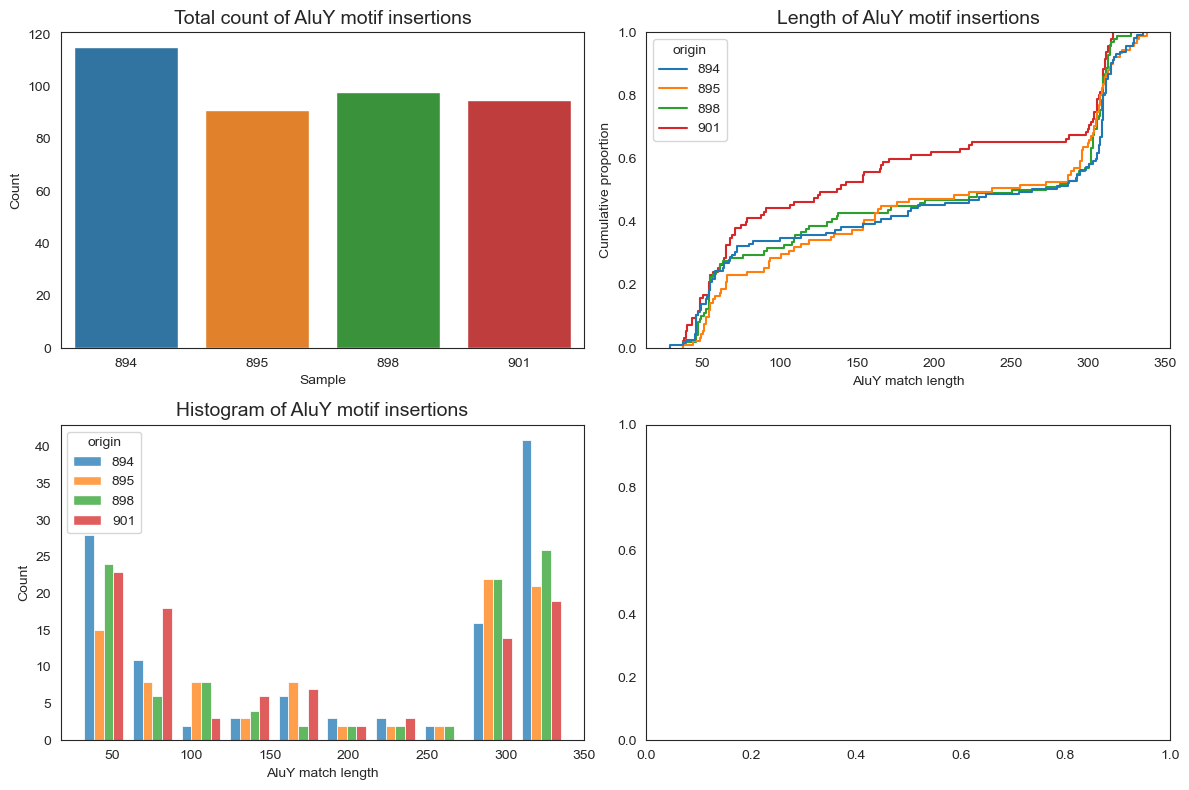

In [505]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (12, 8))
axes = axes.flatten()

sns.countplot(ax = axes[0], data = all_samples, x = 'origin', hue = 'origin')
axes[0].set_title("Total count of AluY motif insertions", size = 14)
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Count")

sns.ecdfplot(ax = axes[1], data = all_samples, x = 'match_len', hue = 'origin')
axes[1].set_title("Length of AluY motif insertions", size = 14)
axes[1].set_xlabel("AluY match length")
axes[1].set_ylabel("Cumulative proportion")

sns.histplot(ax = axes[2], data = all_samples, x = 'match_len', hue = 'origin', multiple="dodge", shrink = 0.8)
axes[2].set_title("Histogram of AluY motif insertions", size = 14)
axes[2].set_xlabel("AluY match length")
axes[2].set_ylabel("Count")

plt.tight_layout()

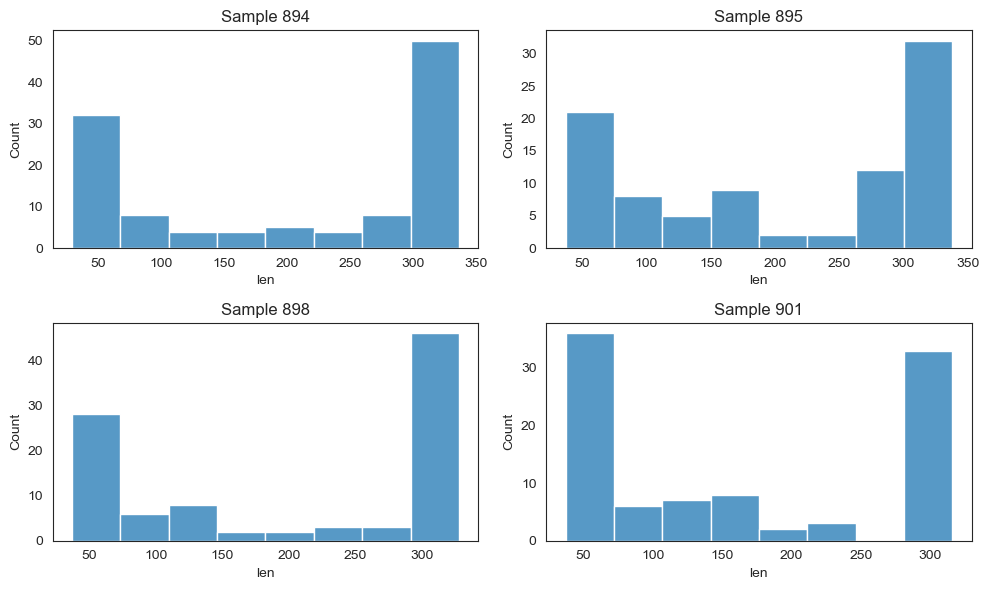

In [447]:
# plots distinct histograms if desired
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (10,6))

for sample, ax in zip(['894', '895', '898', '901'], axes.flatten()):
    sns.histplot(ax = ax, data = all_samples[all_samples['origin'] == sample], x = 'len')
    ax.set_title(f"Sample {sample}")
plt.tight_layout()

Text(0.5, 0.98, 'AluY subfamily read distribution')

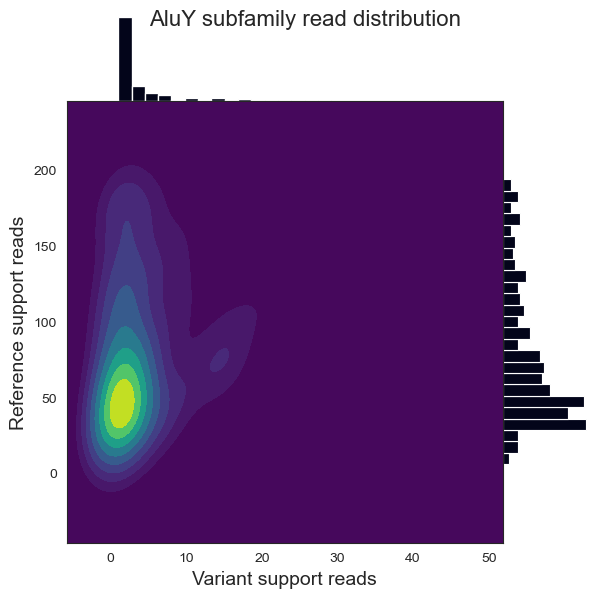

In [552]:
# force reference read limit to <= 200

g = sns.JointGrid(data=all_samples.query("ref_reads <= 200"), x="alt_reads", y="ref_reads", space=0)
g.plot_joint(sns.kdeplot, fill=True, thresh=0, cmap="viridis",)
g.plot_marginals(sns.histplot, color="#03051A", alpha=1, bins=25)
g.set_axis_labels(xlabel = "Variant support reads", ylabel = "Reference support reads", size = 14)
plt.suptitle("AluY subfamily read distribution", size = 16)

# Build dbRIP GFF(s)

`dbrip_alu_ref.csv` obtained from [here](https://lianglab.shinyapps.io/shinydbRIP/) through the extremely arduous process of selecting `reference` annotated variants in all `AluY*`. This could only be downloaded in batches of 1000 because the main batch download link is broken. All three `dbRIP_raw*.csv` files were concatenated into the full `dbRIP_raw.csv`.

Repeated the same to obtain `dbrip_alu_nonref.csv`, with the `Variant Class` field filtered with a floor of `0.0508` (this was the closest I could get to `0.05`).
Note that I had to remove (manually) some entries below, due to an error (?) in curation where the start coord > end coord.

In [360]:
dbrip_alu_ref = pd.read_csv('notebooks/jupyter/20231107/dbrip_alu_ref.csv', index_col = 0)
dbrip_alu_nonref = pd.read_csv('notebooks/jupyter/20231107/dbrip_alu_nonref.csv', index_col = 0)

# manually remove problematic IDs
dbrip_alu_nonref = dbrip_alu_nonref.query("Start < End")


In [365]:
# for ref
dbrip_ref_gff = dbrip_alu_ref[['Chromosome', 'ME_subtype', 'Start', 'End', 'Strand', 'ID', 'ME_category', 'Variant_Class']]
dbrip_ref_gff['source'] = 'dbRIP'
dbrip_ref_gff['score'] = 0 # no score available, but placeholdered
dbrip_ref_gff['frame'] = '.' # no frame available, this is also placeholdered in repeatmasker's gff
dbrip_ref_gff['attribute'] = ['dbRIP_ID "{a}"; ME_category "{b}"; Variant_Class "{c}";'.format(a = ID, b = me_cat, c = varclass) for (index, ID, me_cat, varclass) in dbrip_ref_gff[['ID', 'ME_category', 'Variant_Class']].itertuples()]
dbrip_ref_gff.rename(columns = {'Chromosome': 'seqname', 'ME_subtype': 'feature', 'Start': 'start', 'End': 'end', 'Strand': 'strand'}, inplace=True)
dbrip_ref_gff = dbrip_ref_gff[['seqname', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute']]
dbrip_ref_gff.to_csv('notebooks/jupyter/20231107/dbrip_alu_ref.gff', index = False, header = None, sep = '\t')

# for nonref
dbrip_nonref_gff = dbrip_alu_nonref[['Chromosome', 'ME_subtype', 'Start', 'End', 'Strand', 'ID', 'ME_category', 'Variant_Class']]
dbrip_nonref_gff['source'] = 'dbRIP'
dbrip_nonref_gff['score'] = 0 # no score available, but placeholdered
dbrip_nonref_gff['frame'] = '.' # no frame available, this is also placeholdered in repeatmasker's gff
dbrip_nonref_gff['attribute'] = ['dbRIP_ID "{a}"; ME_category "{b}"; Variant_Class "{c}";'.format(a = ID, b = me_cat, c = varclass) for (index, ID, me_cat, varclass) in dbrip_nonref_gff[['ID', 'ME_category', 'Variant_Class']].itertuples()]
dbrip_nonref_gff.rename(columns = {'Chromosome': 'seqname', 'ME_subtype': 'feature', 'Start': 'start', 'End': 'end', 'Strand': 'strand'}, inplace=True)
dbrip_nonref_gff = dbrip_nonref_gff[['seqname', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute']]
dbrip_nonref_gff.to_csv('notebooks/jupyter/20231107/dbrip_alu_nonref.gff', index = False, header = None, sep = '\t')

/var/folders/d1/_d4s2fqs7_z4dhbkbh6b02xw0000gn/T/ipykernel_27196/1349890345.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dbrip_ref_gff['source'] = 'dbRIP'
/var/folders/d1/_d4s2fqs7_z4dhbkbh6b02xw0000gn/T/ipykernel_27196/1349890345.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dbrip_ref_gff['score'] = 0 # no score available, but placeholdered
/var/folders/d1/_d4s2fqs7_z4dhbkbh6b02xw0000gn/T/ipykernel_27196/1349890345.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice

# bedtools annotations (test with 894)

On savio using an environment with bedtools, run:

```
bedtools annotate -names -both -i notebooks/jupyter/20231107/{sample}_aluY.gff -files {relevant files} > notebooks/jupyter/20231107/{sample}_aluY_anno.gff
```

Where `{sample}` is in the set of `894, 895, 898, 901` and `{relevant files}` are:
```
    repeatmasker: "/global/scratch/users/stacy-l/references/hg38_HGSVC/GRCh38_repeatmasker.bed"
    repeats: "/global/scratch/users/stacy-l/references/hg38_HGSVC/GRCh38_simpleRepeat.bed"
    segdups: "/global/scratch/users/stacy-l/references/hg38_HGSVC/GRCh38_genomicSuperDups.bed"
    censat: "/global/scratch/users/stacy-l/references/hg38_HGSVC/GRCh38_centromeres.bed"
    microsat: "/global/scratch/users/stacy-l/references/hg38_HGSVC/GRCh38_microsat.bed"
    refseq: "/global/scratch/users/stacy-l/references/hg38_HGSVC/GRCh38_ncbiRefSeq.gtf.gz"
    plof: "/global/scratch/users/stacy-l/references/hg38_HGSVC/GRCh38_gnomAD_geneLoF.bed"
```
Plus the `dbrip_alu_ref.gff` & `*nonref.gff` files generated previously.

Sample command:
```
bedtools annotate -names -both -i notebooks/jupyter/20231107/894_aluY.gff \
-files /global/scratch/users/stacy-l/references/hg38_HGSVC/GRCh38_repeatmasker.bed \
/global/scratch/users/stacy-l/references/hg38_HGSVC/GRCh38_simpleRepeat.bed \
/global/scratch/users/stacy-l/references/hg38_HGSVC/GRCh38_genomicSuperDups.bed \
/global/scratch/users/stacy-l/references/hg38_HGSVC/GRCh38_centromeres.bed \
/global/scratch/users/stacy-l/references/hg38_HGSVC/GRCh38_microsat.bed \
/global/scratch/users/stacy-l/references/hg38_HGSVC/GRCh38_ncbiRefSeq.gtf.gz \
/global/scratch/users/stacy-l/references/hg38_HGSVC/GRCh38_gnomAD_geneLoF.bed \
/global/scratch/users/stacy-l/spermSV/notebooks/jupyter/20231107/dbrip_alu_ref.gff \
/global/scratch/users/stacy-l/spermSV/notebooks/jupyter/20231107/dbrip_alu_nonref.gff \
 > notebooks/jupyter/20231107/894_aluY_anno.gff
```

In [527]:
# poverlap = % overlap, where 0% = sequence has no overlap with feature in this file, 1.0 = sequence is completely overlapped by a feature in this file
anno_894 = pd.read_table('notebooks/jupyter/20231107/894_aluY_anno.gff', index_col = False, 
                        names = ['seqname', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute', 
                        'repeatMasker_count', 'repeatMasker_poverlap', 'simpleRepeat_count', 'simpleRepeat_poverlap', 
                        'genomicSuperDup_count', 'genomicSuperDup_poverlap', 'centromeres_count', 'centromeres_poverlap', 
                        'microsat_count', 'microsat_poverlap', 'refseq_count', 'refseq_poverlap', 'plof_count', 'plof_overlap',
                        'dbrip_ref_count', 'dbrip_ref_poverlap','dbrip_nonref_count', 'dbrip_nonref_poverlap' ])

# re-expand attribute column
anno_894[['motif', 'sniffles_ID', 'support']] = anno_894['attribute'].str.split(";", expand = True)
anno_894.drop(columns='attribute', inplace = True)
anno_894.head()


,seqname,source,feature,start,end,score,strand,frame,repeatMasker_count,repeatMasker_poverlap,...,refseq_poverlap,plof_count,plof_overlap,dbrip_ref_count,dbrip_ref_poverlap,dbrip_nonref_count,dbrip_nonref_poverlap,motif,sniffles_ID,support
0,chr1,RepeatMasker_SINE,similarity,748234,748549,0.3,+,.,3,0.882911,...,1.0,0,0.0,0,0.0,0,0.0,"motif ""AluYb8""","sniffles_ID ""Sniffles2.INS.24S0""","support ""(65, 12)"""
1,chr1,RepeatMasker_SINE,similarity,16733034,16733344,1.0,-,.,1,0.443730,...,0.0,0,0.0,0,0.0,0,0.0,"motif ""AluYb8""","sniffles_ID ""Sniffles2.INS.1A9S0""","support ""(203, 21)"""
2,chr1,RepeatMasker_SINE,similarity,27107090,27107256,6.0,+,.,1,0.940120,...,1.0,1,1.0,0,0.0,0,0.0,"motif ""AluYk3""","sniffles_ID ""Sniffles2.INS.210S0""","support ""(43, 3)"""
3,chr1,RepeatMasker_SINE,similarity,144117973,144118272,0.7,+,.,1,1.000000,...,1.0,0,0.0,0,0.0,0,0.0,"motif ""AluY""","sniffles_ID ""Sniffles2.INS.550S0""","support ""(28, 1)"""
4,chr10,RepeatMasker_SINE,similarity,73687016,73687346,0.6,+,.,3,0.661631,...,1.0,1,1.0,0,0.0,0,0.0,"motif ""AluYa5""","sniffles_ID ""Sniffles2.INS.457S1""","support ""(46, 1)"""


In [529]:
# only view counts for sorting by absolute overlap counts
anno_894_counts = anno_894[['seqname', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'motif', 'sniffles_ID', 'support',
                            'repeatMasker_count', 'simpleRepeat_count', 'genomicSuperDup_count', 'centromeres_count', 
                            'microsat_count', 'refseq_count', 'plof_count', 'dbrip_ref_count', 'dbrip_nonref_count']]